# Movie Recommender System

Interactive explorer for the [MovieLens ml-latest-small](https://grouplens.org/datasets/movielens/) dataset (9,742 movies).  
Use the controls in each section to search and filter movies in real time.

In [1]:
%matplotlib inline
from modules.recommender import Recommender
import ipywidgets as widgets
from IPython.display import display

recommender = Recommender(
    'data/ml-latest-small/movies.csv',
    'data/ml-latest-small/ratings.csv'
)

# Pre-compute lookup values — avoid __getattr__ calls for 9k movies
genres_sorted  = sorted(recommender.get_all_genres())
year_min       = min(m.year for m in recommender.movies if m.year > 0)
year_max       = max(m.year for m in recommender.movies if m.year > 0)
decades_sorted = sorted(set(f"{(m.year // 10) * 10}s" for m in recommender.movies if m.year > 0))

print(f'Loaded {len(recommender.movies)} movies  |  '
      f'{len(genres_sorted)} genres  |  '
      f'Years {year_min}\u2013{year_max}')

Loaded 9742 movies  |  19 genres  |  Years 1902–2018


---
## Interactive Movie Explorer

In [2]:
# ── Search by Title ───────────────────────────────────────────────────────────
title_input = widgets.Text(
    placeholder='e.g. Star Wars, Batman, Toy…',
    description='Title:',
    layout=widgets.Layout(width='380px')
)
title_topn = widgets.IntSlider(
    value=10, min=1, max=30,
    description='Max results:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)
title_out = widgets.Output()

def _search_title(change):
    title_out.clear_output(wait=True)
    with title_out:
        query = title_input.value.strip()
        if not query:
            print('Type a title fragment to search.')
            return
        hits = [m for m in recommender.movies if query.lower() in m.title.lower()]
        hits.sort(key=lambda m: m.rating, reverse=True)
        shown = hits[:title_topn.value]
        print(f'{len(hits)} match(es) — showing top {len(shown)}:\n')
        for i, m in enumerate(shown, 1):
            genres = ', '.join(m.genre) if m.genre else '—'
            print(f'  {i:>2}. {m.title} ({m.year})  |  {genres}  |  ★ {m.rating:.2f}')

title_input.observe(_search_title, names='value')
title_topn.observe(_search_title, names='value')

display(widgets.VBox([
    widgets.HTML('<b style="font-size:1.05em">Search by Title</b>'),
    widgets.HBox([title_input, title_topn]),
    title_out
]))

In [3]:
# ── Filter by Genre ───────────────────────────────────────────────────────────
genre_dd = widgets.Dropdown(
    options=genres_sorted, value='Action', description='Genre:'
)
genre_topn = widgets.IntSlider(
    value=10, min=1, max=30,
    description='Top N:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px')
)
genre_out = widgets.Output()

def _filter_genre(change):
    genre_out.clear_output(wait=True)
    with genre_out:
        results = recommender.recommend_by_genre(genre_dd.value, genre_topn.value)
        print(f'Top {len(results)} {genre_dd.value} movies:\n')
        for i, m in enumerate(results, 1):
            print(f'  {i:>2}. {m.title} ({m.year})  |  {", ".join(m.genre)}  |  ★ {m.rating:.2f}')

genre_dd.observe(_filter_genre, names='value')
genre_topn.observe(_filter_genre, names='value')

with genre_out:
    print('Select a genre above to see results.')

display(widgets.VBox([
    widgets.HTML('<b style="font-size:1.05em">Filter by Genre</b>'),
    widgets.HBox([genre_dd, genre_topn]),
    genre_out
]))

In [4]:
# ── Filter by Release Year ────────────────────────────────────────────────────
year_slider = widgets.IntSlider(
    value=2000, min=year_min, max=year_max, step=1,
    description='Year:',
    continuous_update=False,
    layout=widgets.Layout(width='420px')
)
year_topn = widgets.IntSlider(
    value=10, min=1, max=30,
    description='Top N:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='260px')
)
year_out = widgets.Output()

def _filter_year(change):
    year_out.clear_output(wait=True)
    with year_out:
        results = recommender.recommend_by_year(year_slider.value, year_topn.value)
        if not results:
            print(f'No movies found for {year_slider.value}.')
            return
        print(f'Top {len(results)} movies from {year_slider.value}:\n')
        for i, m in enumerate(results, 1):
            print(f'  {i:>2}. {m.title}  |  {", ".join(m.genre)}  |  ★ {m.rating:.2f}')

year_slider.observe(_filter_year, names='value')
year_topn.observe(_filter_year, names='value')

with year_out:
    print('Move the slider to pick a year.')

display(widgets.VBox([
    widgets.HTML('<b style="font-size:1.05em">Filter by Release Year</b>'),
    widgets.HBox([year_slider, year_topn]),
    year_out
]))

In [5]:
# ── Filter by Decade ──────────────────────────────────────────────────────────
decade_dd = widgets.Dropdown(
    options=decades_sorted, value='2000s', description='Decade:'
)
decade_topn = widgets.IntSlider(
    value=10, min=1, max=30,
    description='Top N:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px')
)
decade_out = widgets.Output()

def _filter_decade(change):
    decade_out.clear_output(wait=True)
    with decade_out:
        results = recommender.recommend_by_decade(decade_dd.value, decade_topn.value)
        print(f'Top {len(results)} movies from the {decade_dd.value}:\n')
        for i, m in enumerate(results, 1):
            print(f'  {i:>2}. {m.title} ({m.year})  |  {", ".join(m.genre)}  |  ★ {m.rating:.2f}')

decade_dd.observe(_filter_decade, names='value')
decade_topn.observe(_filter_decade, names='value')

with decade_out:
    print('Select a decade above to see results.')

display(widgets.VBox([
    widgets.HTML('<b style="font-size:1.05em">Filter by Decade</b>'),
    widgets.HBox([decade_dd, decade_topn]),
    decade_out
]))

In [6]:
# ── Filter by Two Genres (intersection) ──────────────────────────────────────
genre1_dd = widgets.Dropdown(
    options=genres_sorted, value='Action', description='Genre 1:'
)
genre2_dd = widgets.Dropdown(
    options=genres_sorted, value='Drama', description='Genre 2:'
)
two_genre_topn = widgets.IntSlider(
    value=10, min=1, max=30,
    description='Top N:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='260px')
)
two_genre_out = widgets.Output()

def _filter_two_genres(change):
    two_genre_out.clear_output(wait=True)
    with two_genre_out:
        if genre1_dd.value == genre2_dd.value:
            print('Select two different genres.')
            return
        results = recommender.recommend_by_multiple_genres(
            genre1_dd.value, genre2_dd.value, two_genre_topn.value
        )
        label = f'{genre1_dd.value} ∩ {genre2_dd.value}'
        if not results:
            print(f'No movies found in both {label}.')
            return
        print(f'Top {len(results)} movies in {label}:\n')
        for i, m in enumerate(results, 1):
            print(f'  {i:>2}. {m.title} ({m.year})  |  {", ".join(m.genre)}  |  ★ {m.rating:.2f}')

genre1_dd.observe(_filter_two_genres, names='value')
genre2_dd.observe(_filter_two_genres, names='value')
two_genre_topn.observe(_filter_two_genres, names='value')

with two_genre_out:
    print('Select two genres above to see their intersection.')

display(widgets.VBox([
    widgets.HTML('<b style="font-size:1.05em">Filter by Two Genres (intersection)</b>'),
    widgets.HBox([genre1_dd, genre2_dd, two_genre_topn]),
    two_genre_out
]))

In [7]:
# ── Filter by Minimum Rating ──────────────────────────────────────────────────
rating_slider = widgets.FloatSlider(
    value=4.0, min=0.0, max=5.0, step=0.1,
    description='Min rating:',
    continuous_update=False,
    readout_format='.1f',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
rating_topn = widgets.IntSlider(
    value=15, min=1, max=50,
    description='Max results:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)
rating_out = widgets.Output()

def _filter_rating(change):
    rating_out.clear_output(wait=True)
    with rating_out:
        # recommend_top_rated uses filter() internally to apply the min_rating threshold
        results = recommender.recommend_top_rated(top_n=rating_topn.value, min_rating=rating_slider.value)
        if not results:
            print(f'No movies rated ≥ {rating_slider.value:.1f}.')
            return
        print(f'{len(results)} movies rated ≥ {rating_slider.value:.1f}:\n')
        for i, m in enumerate(results, 1):
            genres = ', '.join(m.genre) if m.genre else '—'
            print(f'  {i:>2}. {m.title} ({m.year})  |  {genres}  |  ★ {m.rating:.2f}')

rating_slider.observe(_filter_rating, names='value')
rating_topn.observe(_filter_rating, names='value')

with rating_out:
    print('Move the slider to set a minimum rating.')

display(widgets.VBox([
    widgets.HTML('<b style="font-size:1.05em">Filter by Minimum Rating</b>'),
    widgets.HBox([rating_slider, rating_topn]),
    rating_out
]))

---
## Statistics & Visualization

In [8]:
# Rating statistics — numpy functions dispatched via zip; reduce sums independently for auditability
stats = recommender.get_rating_stats()
print('Rating statistics across all movies:')
print(f"  Mean:   {stats['mean']:.3f}")
print(f"  Median: {stats['median']:.3f}")
print(f"  Std:    {stats['std']:.3f}")
print(f"  Min:    {stats['min']:.3f}")
print(f"  Max:    {stats['max']:.3f}")
print(f"  Total:  {stats['total']:.1f}  (summed via reduce, cross-checks mean × count)")

Rating statistics across all movies:
  Mean:   3.256
  Median: 3.417
  Std:    0.880
  Min:    0.000
  Max:    5.000
  Total:  31724.0  (summed via reduce, cross-checks mean × count)


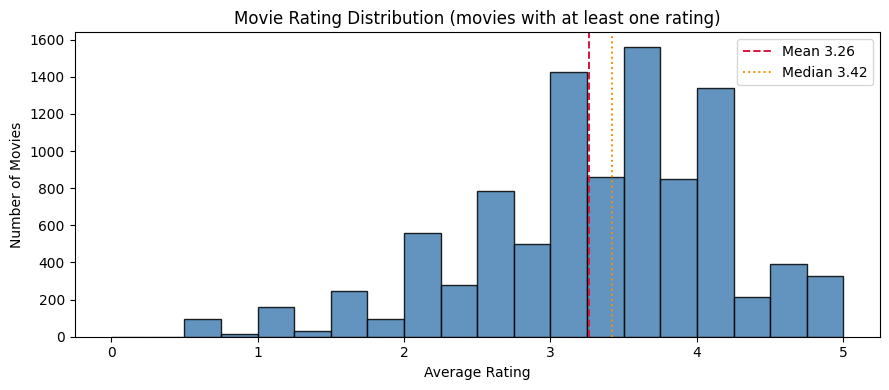

In [9]:
# Rating distribution histogram (matplotlib)
import matplotlib.pyplot as plt
import numpy as np

ratings = [m.rating for m in recommender.movies if m.rating > 0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ratings, bins=20, range=(0, 5), edgecolor='black', color='steelblue', alpha=0.85)
ax.axvline(float(np.mean(ratings)), color='crimson', linestyle='--', linewidth=1.4, label=f'Mean {np.mean(ratings):.2f}')
ax.axvline(np.median(ratings), color='darkorange', linestyle=':', linewidth=1.4, label=f'Median {np.median(ratings):.2f}')
ax.set_title('Movie Rating Distribution (movies with at least one rating)')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.show()

---
## System Walkthrough

The cells below show how each Python feature integrates into the recommendation workflow —
not as isolated demos, but as working parts of the system.

In [10]:
# __getattr__ — decade and is_classic are computed dynamically from Movie.year
for movie in recommender.recommend_top_rated(5):
    print(f"{movie.title} ({movie.year})  decade={movie.decade}  classic={movie.is_classic}")

Lamerica (1994)  decade=1990s  classic=False
Heidi Fleiss: Hollywood Madam (1995)  decade=1990s  classic=False
Awfully Big Adventure, An (1995)  decade=1990s  classic=False
Live Nude Girls (1995)  decade=1990s  classic=False
In the Realm of the Senses (Ai no corrida) (1976)  decade=1970s  classic=True


In [11]:
# Generator with predicate — stream_movies lazily yields only matching movies
# without building a full filtered list first; useful when scanning large datasets
print('Top-rated Action movies (streamed lazily, rating >= 4.0):')
action_stream = recommender.stream_movies(
    predicate=lambda m: 'Action' in m.genre and m.rating >= 4.0
)
for i, movie in enumerate(action_stream, 1):
    print(f'  {i}. {movie.title} ({movie.year})  ★ {movie.rating:.2f}')
    if i == 5:
        break

Top-rated Action movies (streamed lazily, rating >= 4.0):
  1. Braveheart (1995)  ★ 4.03
  2. Star Wars: Episode IV - A New Hope (1977)  ★ 4.23
  3. New York Cop (Nyû Yôku no koppu) (1993)  ★ 4.50
  4. Léon: The Professional (a.k.a. The Professional) (Léon) (1994)  ★ 4.02
  5. Blade Runner (1982)  ★ 4.10


In [12]:
# Set operations — get_all_genres uses a set comprehension; recommend_by_multiple_genres uses &
all_genres = recommender.get_all_genres()
print(f'All unique genres ({len(all_genres)} total):', sorted(all_genres))

All unique genres (19 total): ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [13]:
# Recursion — _recursive_top_n pulls the max each call, then recurses on the remainder
print('Top 5 via recursion:')
for i, m in enumerate(recommender._recursive_top_n(recommender.movies, 5), 1):
    print(f'  {i}. {m.title} ({m.rating})')

Top 5 via recursion:
  1. Lamerica (5.0)
  2. Heidi Fleiss: Hollywood Madam (5.0)
  3. Awfully Big Adventure, An (5.0)
  4. Live Nude Girls (5.0)
  5. In the Realm of the Senses (Ai no corrida) (5.0)


In [14]:
# Built-in libs — random.sample and itertools.combinations
print('5 random picks:')
for m in recommender.recommend_random(5):
    print(f'  {m.title} ({m.rating:.2f})')

print('\nPairs from top 4 (itertools.combinations):')
for m1, m2 in recommender.get_movie_pairs(top_n=4):
    print(f'  {m1.title}  \u2194  {m2.title}')

5 random picks:
  Can't Buy Me Love (3.25)
  Johnny Be Good (3.00)
  Night Watch (Nochnoy dozor) (3.25)
  Watcher in the Woods, The (3.00)
  Hamlet (3.50)

Pairs from top 4 (itertools.combinations):
  Lamerica  ↔  Heidi Fleiss: Hollywood Madam
  Lamerica  ↔  Awfully Big Adventure, An
  Lamerica  ↔  Live Nude Girls
  Heidi Fleiss: Hollywood Madam  ↔  Awfully Big Adventure, An
  Heidi Fleiss: Hollywood Madam  ↔  Live Nude Girls
  Awfully Big Adventure, An  ↔  Live Nude Girls


In [15]:
# rank_results — uses enumerate to produce a numbered list from any recommendation call
print(recommender.rank_results(
    recommender.recommend_top_rated(top_n=5, min_rating=3.5),
    header='Top 5 (well-rated, min 3.5):'
))

print()

# map (inside load_data) + zip/reduce (inside get_rating_stats) — verify consistency
stats = recommender.get_rating_stats()
estimated_mean = stats['total'] / len(recommender.movies)
print(f"reduce total : {stats['total']:.1f}")
print(f"÷ {len(recommender.movies)} movies  = {estimated_mean:.4f}  (via reduce)")
print(f"numpy  mean  = {stats['mean']:.4f}  (via zip dispatch)")
print("Both match — reduce independently confirms numpy output.")

Top 5 (well-rated, min 3.5):
  1. Lamerica (1994) is a Adventure, Drama movie with a rating of 5.0
  2. Heidi Fleiss: Hollywood Madam (1995) is a Documentary movie with a rating of 5.0
  3. Awfully Big Adventure, An (1995) is a Drama movie with a rating of 5.0
  4. Live Nude Girls (1995) is a Comedy movie with a rating of 5.0
  5. In the Realm of the Senses (Ai no corrida) (1976) is a Drama movie with a rating of 5.0

reduce total : 31724.0
÷ 9742 movies  = 3.2564  (via reduce)
numpy  mean  = 3.2564  (via zip dispatch)
Both match — reduce independently confirms numpy output.


In [16]:
# Dict comprehension — {genre: count}
genre_counts = recommender.get_genre_counts()
print('Movies per genre (top 10 by count):')
for genre, count in sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'  {genre}: {count}')

Movies per genre (top 10 by count):
  Drama: 4361
  Comedy: 3756
  Thriller: 1894
  Action: 1828
  Romance: 1596
  Adventure: 1263
  Crime: 1199
  Sci-Fi: 980
  Horror: 978
  Fantasy: 779
